In [1]:
# # CNN Model for West African Rainfall Using PyTorch

In [2]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置显示字体为 Times New Roman
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams["axes.unicode_minus"] = False

#图像清晰度调整
%config InlineBackend.figure_format = 'retina'

In [3]:
# %%
# Set local data directory

DATA_DIR = Path("/Users/camus/Desktop/dissertation/meeting1/RainfallWestAfrica_Resources")
runid = "ERA5"

In [4]:
# %%
# Set random seed for reproducibility

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
# %%
def load_npy(name):
    path = DATA_DIR / f"{runid}_{name}_regr_onescale.npy"
    arr = np.load(path).astype(np.float32)
    print(
        f"{name:25s}",
        "shape:", arr.shape,
        "min:", arr.min(),
        "max:", arr.max(),
        "NaN:", np.isnan(arr).sum()
    )
    return arr

In [6]:
# ## 1. Load Rainfall Target

In [7]:
# %%
precip = load_npy("Precip")

Precip                    shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0


In [8]:
# ## 2. Load Meteorological Predictor Variables

In [9]:
# %%
moisture_divergence = load_npy("VImoistureDivergence")
vi_water = load_npy("VIwater")
cloud_cover = load_npy("CloudCover")
evaporation_rate = load_npy("EvaporationRate")
skin_temperature = load_npy("SkinTemperature")
sea_level_pressure = load_npy("SeaLevelPressure")
wind_speed_10m = load_npy("10mWindSpeed")

VImoistureDivergence      shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
VIwater                   shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
CloudCover                shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
EvaporationRate           shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
SkinTemperature           shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
SeaLevelPressure          shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0
10mWindSpeed              shape: (344, 11, 13) min: 0.0 max: 1.0 NaN: 0


In [10]:
# ## 3. Prepare CNN Input and Output

In [12]:
# %%
# Crop rainfall target by removing boundary grid cells.
# Original rainfall shape: (344, 11, 13)
# Cropped rainfall shape:  (344, 9, 11)

precip_cropped = precip[:, 1:-1, 1:-1]

print("Original precip shape:", precip.shape)
print("Cropped precip shape:", precip_cropped.shape)

Original precip shape: (344, 11, 13)
Cropped precip shape: (344, 9, 11)


In [13]:
# %%
# Remove the final timestep from training/validation.
# The final timestep will be used later as a test example.

X_variables = [
    moisture_divergence[:-1],
    vi_water[:-1],
    cloud_cover[:-1],
    evaporation_rate[:-1],
    skin_temperature[:-1],
    sea_level_pressure[:-1],
    wind_speed_10m[:-1],
]

y_data = precip_cropped[:-1]

# Stack variables as channels.
# Initial shape after stack: (time, lat, lon, channels)

X = np.stack(X_variables, axis=-1)

# Convert to PyTorch format: (time, channels, lat, lon)

X = np.transpose(X, (0, 3, 1, 2))

# Add channel dimension to y: (time, 1, lat, lon)

y = y_data[:, np.newaxis, :, :]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (343, 7, 11, 13)
y shape: (343, 1, 9, 11)


In [14]:
# %%
# Train-validation split

x_train = X[0:318]
y_train = y[0:318]

x_val = X[318:344]
y_val = y[318:344]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

x_train: (318, 7, 11, 13)
y_train: (318, 1, 9, 11)
x_val: (25, 7, 11, 13)
y_val: (25, 1, 9, 11)


In [15]:
# %%
# Convert numpy arrays to PyTorch tensors

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=25,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=25,
    shuffle=False
)

In [16]:
# ## 4. Build CNN Model

In [17]:
# %%
class RainfallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(
                in_channels=7,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(16),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            # This layer reduces spatial size from 11 x 13 to 9 x 11
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                padding=0
            ),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(
                in_channels=64,
                out_channels=1,
                kernel_size=1,
                padding=0
            ),
            nn.ReLU()
        )

    def forward(self, x):
        return self.model(x)

In [18]:
# %%
model = RainfallCNN().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

print(model)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


RainfallCNN(
  (model): Sequential(
    (0): Conv2d(7, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
    (13): ReLU()
  )
)


In [19]:
# ## 5. Train CNN Model

In [20]:
# %%
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)

In [21]:
# %%
epochs = 100
patience = 3

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(epochs):
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"train loss: {train_loss:.6f} | "
        f"val loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

# Restore best model
model.load_state_dict(best_model_state)
print("Best validation loss:", best_val_loss)

Epoch 001 | train loss: 0.040204 | val loss: 0.064542
Epoch 002 | train loss: 0.011572 | val loss: 0.032791
Epoch 003 | train loss: 0.007813 | val loss: 0.011156
Epoch 004 | train loss: 0.005774 | val loss: 0.005207
Epoch 005 | train loss: 0.004586 | val loss: 0.004073
Epoch 006 | train loss: 0.003794 | val loss: 0.003728
Epoch 007 | train loss: 0.003383 | val loss: 0.003343
Epoch 008 | train loss: 0.003152 | val loss: 0.003007
Epoch 009 | train loss: 0.002776 | val loss: 0.003176
Epoch 010 | train loss: 0.002570 | val loss: 0.002760
Epoch 011 | train loss: 0.002425 | val loss: 0.002440
Epoch 012 | train loss: 0.002356 | val loss: 0.002757
Epoch 013 | train loss: 0.002308 | val loss: 0.002287
Epoch 014 | train loss: 0.002106 | val loss: 0.002525
Epoch 015 | train loss: 0.001965 | val loss: 0.002281
Epoch 016 | train loss: 0.001943 | val loss: 0.002040
Epoch 017 | train loss: 0.002086 | val loss: 0.002179
Epoch 018 | train loss: 0.001775 | val loss: 0.001876
Epoch 019 | train loss: 0.00

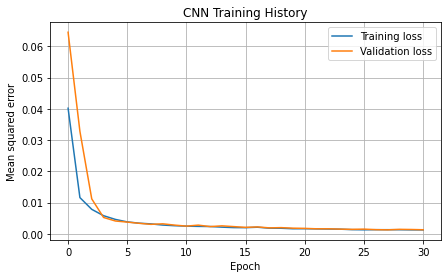

In [22]:
# %%
# Plot training and validation loss

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("CNN Training History")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# ## 6. Predict Rainfall for the Final Timestep

In [24]:
# %%
x_test_last = np.stack(
    [
        moisture_divergence[-1],
        vi_water[-1],
        cloud_cover[-1],
        evaporation_rate[-1],
        skin_temperature[-1],
        sea_level_pressure[-1],
        wind_speed_10m[-1],
    ],
    axis=-1
)

# Convert from (lat, lon, channels) to (channels, lat, lon)
x_test_last = np.transpose(x_test_last, (2, 0, 1))

# Add batch dimension: (1, channels, lat, lon)
x_test = x_test_last[np.newaxis, :, :, :]

x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)

print("x_test shape:", x_test.shape)

x_test shape: (1, 7, 11, 13)


In [25]:
# %%
model.eval()

with torch.no_grad():
    pred = model(x_test_tensor)

pred_rain = pred.cpu().numpy()[0, 0, :, :]

print("Prediction shape:", pred.shape)
print("Predicted rainfall map shape:", pred_rain.shape)
print("Prediction min:", pred_rain.min())
print("Prediction max:", pred_rain.max())

Prediction shape: torch.Size([1, 1, 9, 11])
Predicted rainfall map shape: (9, 11)
Prediction min: 0.0
Prediction max: 0.6935008


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


In [26]:
# ## 7. Plot Predicted Rainfall

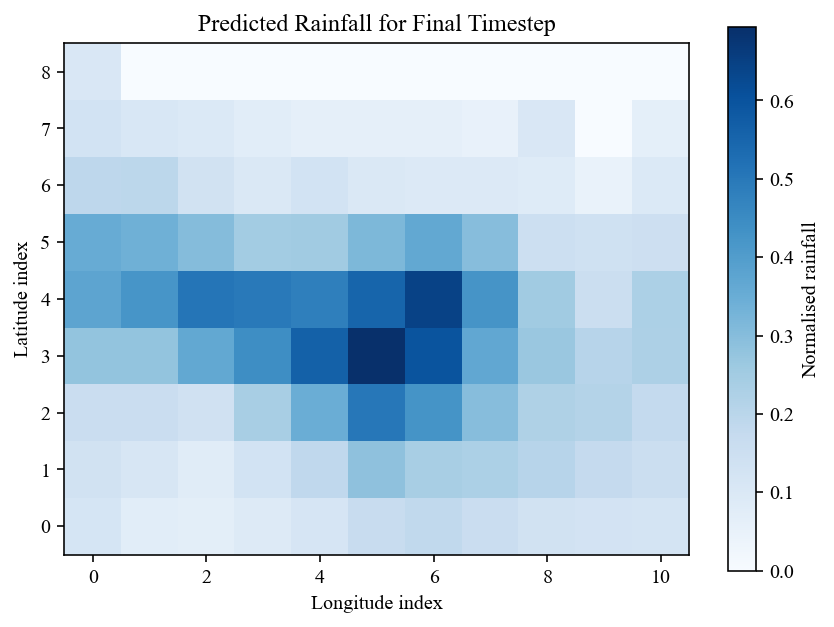

In [32]:
# %%
plt.figure(figsize=(7, 5))
plt.imshow(pred_rain, origin="lower", cmap="Blues")
plt.colorbar(label="Normalised rainfall")
plt.title("Predicted Rainfall for Final Timestep")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()

In [28]:
# ## 8. Compare Prediction with True Rainfall

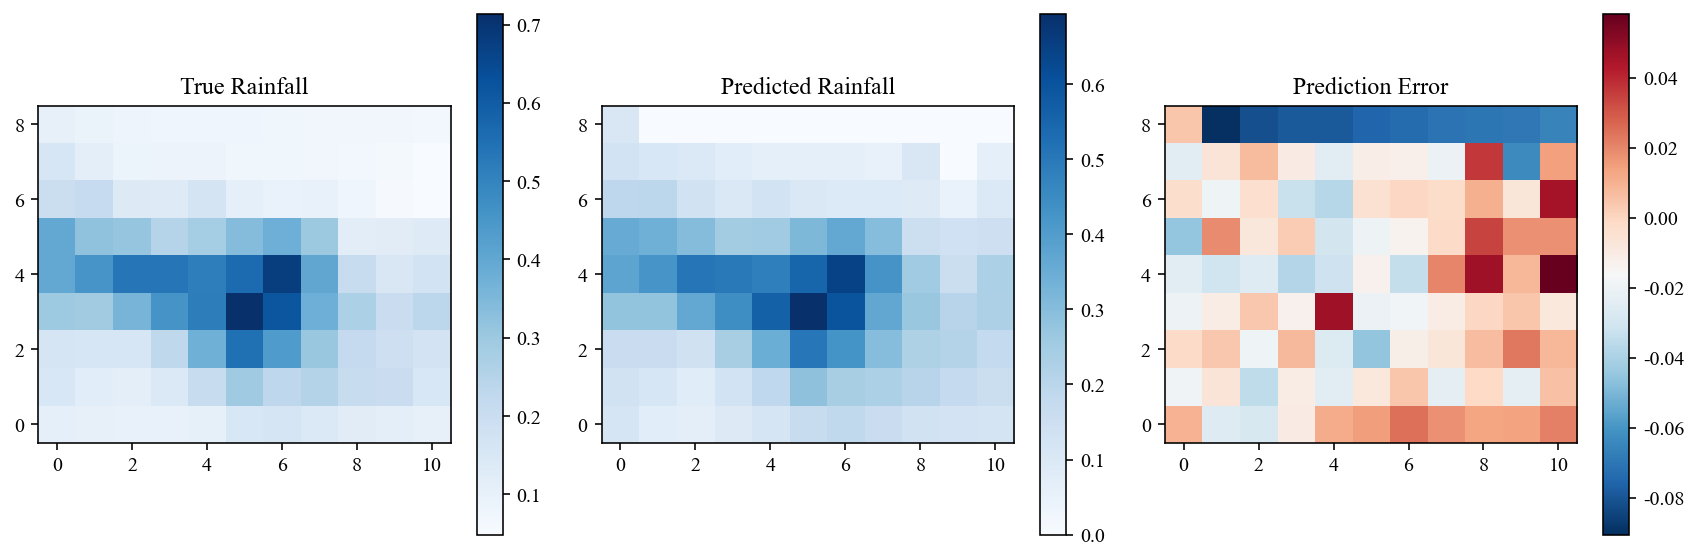

In [33]:
# %%
true_rain = precip_cropped[-1]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(true_rain, origin="lower", cmap="Blues")
plt.colorbar()
plt.title("True Rainfall")

plt.subplot(1, 3, 2)
plt.imshow(pred_rain, origin="lower", cmap="Blues")
plt.colorbar()
plt.title("Predicted Rainfall")

plt.subplot(1, 3, 3)
plt.imshow(pred_rain - true_rain, origin="lower", cmap="RdBu_r")
plt.colorbar()
plt.title("Prediction Error")

plt.tight_layout()
plt.show()

In [30]:
# %%
mse = np.mean((pred_rain - true_rain) ** 2)
mae = np.mean(np.abs(pred_rain - true_rain))

print("Final timestep MSE:", mse)
print("Final timestep MAE:", mae)

Final timestep MSE: 0.0010414141
Final timestep MAE: 0.023946494


In [2]:
# # Advanced Deep Learning Models for West African Rainfall Regression
#
# Models:
# 1. Baseline CNN
# 2. Residual CNN
# 3. Small U-Net
# 4. ConvLSTM

In [3]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [4]:
# %%
DATA_DIR = Path("/Users/camus/Desktop/dissertation/meeting1/RainfallWestAfrica_Resources")
runid = "ERA5"

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
# %%
variable_names = [
    "VImoistureDivergence",
    "VIwater",
    "CloudCover",
    "EvaporationRate",
    "SkinTemperature",
    "SeaLevelPressure",
    "10mWindSpeed",
]

def load_npy(name):
    path = DATA_DIR / f"{runid}_{name}_regr_onescale.npy"
    arr = np.load(path).astype(np.float32)
    print(f"{name:25s}", arr.shape, arr.min(), arr.max(), "NaN:", np.isnan(arr).sum())
    return arr

In [6]:
# ## 1. Load Data

In [7]:
# %%
precip = load_npy("Precip")

variables = {
    name: load_npy(name)
    for name in variable_names
}

Precip                    (344, 11, 13) 0.0 1.0 NaN: 0
VImoistureDivergence      (344, 11, 13) 0.0 1.0 NaN: 0
VIwater                   (344, 11, 13) 0.0 1.0 NaN: 0
CloudCover                (344, 11, 13) 0.0 1.0 NaN: 0
EvaporationRate           (344, 11, 13) 0.0 1.0 NaN: 0
SkinTemperature           (344, 11, 13) 0.0 1.0 NaN: 0
SeaLevelPressure          (344, 11, 13) 0.0 1.0 NaN: 0
10mWindSpeed              (344, 11, 13) 0.0 1.0 NaN: 0


In [8]:
# ## 2. Build Input and Target Arrays

In [9]:
# Rainfall target: crop boundary cells to match model output size.
# Original rainfall: (344, 11, 13)
# Cropped rainfall:  (344, 9, 11)

precip_cropped = precip[:, 1:-1, 1:-1]

print("Original precipitation:", precip.shape)
print("Cropped precipitation:", precip_cropped.shape)

Original precipitation: (344, 11, 13)
Cropped precipitation: (344, 9, 11)


In [10]:
# Full predictor tensor in PyTorch format:
# X_all shape: (time, channels, lat, lon)

X_all = np.stack(
    [variables[name] for name in variable_names],
    axis=1
)

y_all = precip_cropped[:, np.newaxis, :, :]

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)

X_all: (344, 7, 11, 13)
y_all: (344, 1, 9, 11)


In [11]:
# ## 3. Create Same-Month and ConvLSTM Datasets
#
# ConvLSTM uses sequences:
#
# `[t-2, t-1, t] -> rainfall at t`
#
# To make comparison fair, CNN / ResNet / U-Net also predict the same target timesteps.

In [12]:
# %%
seq_len = 3

# Exclude final timestep as held-out test, same as previous experiment.
# Available supervised targets: t = seq_len-1 ... 342

target_indices = np.arange(seq_len - 1, X_all.shape[0] - 1)

print("Number of supervised samples:", len(target_indices))
print("First target index:", target_indices[0])
print("Last target index:", target_indices[-1])

Number of supervised samples: 341
First target index: 2
Last target index: 342


In [13]:
# %%
# Same-month inputs for CNN / ResNet / U-Net:
# X_spatial[i] = predictors at target time t
# y[i] = rainfall at target time t

X_spatial = X_all[target_indices]
y = y_all[target_indices]

print("X_spatial:", X_spatial.shape)
print("y:", y.shape)

X_spatial: (341, 7, 11, 13)
y: (341, 1, 9, 11)


In [14]:
# %%
# Sequence inputs for ConvLSTM:
# X_sequence[i] = predictors from t-seq_len+1 to t
# y[i] = rainfall at t

X_sequence = []

for t in target_indices:
    sequence = X_all[t - seq_len + 1 : t + 1]
    X_sequence.append(sequence)

X_sequence = np.stack(X_sequence, axis=0)

print("X_sequence:", X_sequence.shape)
print("y:", y.shape)

X_sequence: (341, 3, 7, 11, 13)
y: (341, 1, 9, 11)


In [15]:
# ## 4. Train / Validation Split

In [16]:
# %%
# Chronological split.
# Use approximately the same training length as previous experiments.

n_train = 318

X_spatial_train = X_spatial[:n_train]
X_spatial_val = X_spatial[n_train:]

X_sequence_train = X_sequence[:n_train]
X_sequence_val = X_sequence[n_train:]

y_train = y[:n_train]
y_val = y[n_train:]

print("Spatial train:", X_spatial_train.shape)
print("Spatial val:", X_spatial_val.shape)
print("Sequence train:", X_sequence_train.shape)
print("Sequence val:", X_sequence_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Spatial train: (318, 7, 11, 13)
Spatial val: (23, 7, 11, 13)
Sequence train: (318, 3, 7, 11, 13)
Sequence val: (23, 3, 7, 11, 13)
y_train: (318, 1, 9, 11)
y_val: (23, 1, 9, 11)


In [17]:
# %%
def make_loader(X_train, y_train, X_val, y_val, batch_size=25):
    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader

In [18]:
# %%
spatial_train_loader, spatial_val_loader = make_loader(
    X_spatial_train,
    y_train,
    X_spatial_val,
    y_val
)

sequence_train_loader, sequence_val_loader = make_loader(
    X_sequence_train,
    y_train,
    X_sequence_val,
    y_val
)

In [19]:
# ## 5. Evaluation Metrics

In [20]:
# %%
def regression_metrics(predictions, targets):
    """
    predictions and targets are torch tensors.
    """
    mse = torch.mean((predictions - targets) ** 2).item()
    mae = torch.mean(torch.abs(predictions - targets)).item()
    rmse = np.sqrt(mse)

    pred_flat = predictions.detach().cpu().numpy().reshape(-1)
    true_flat = targets.detach().cpu().numpy().reshape(-1)

    if np.std(pred_flat) == 0 or np.std(true_flat) == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(pred_flat, true_flat)[0, 1]

    return {
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "corr": corr,
    }

In [21]:
# ## 6. Model 1: Baseline CNN

In [22]:
# %%
class BaselineCNN(nn.Module):
    def __init__(self, in_channels=7):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 1, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.model(x)

In [23]:
# ## 7. Model 2: Residual CNN

In [24]:
# %%
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),

            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class ResNetCNN(nn.Module):
    def __init__(self, in_channels=7):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.res1 = ResidualBlock(32)

        self.up_channels = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.res2 = ResidualBlock(64)

        # Reduce 11 x 13 -> 9 x 11
        self.valid_conv = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.output = nn.Sequential(
            nn.Conv2d(64, 1, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(x)
        x = self.up_channels(x)
        x = self.res2(x)
        x = self.valid_conv(x)
        x = self.output(x)
        return x

In [25]:
# ## 8. Model 3: Small U-Net Regression Model

In [26]:
# %%
def pad_to_match(x, target):
    """
    Pad tensor x so that its spatial dimensions match target.
    """
    diff_h = target.shape[-2] - x.shape[-2]
    diff_w = target.shape[-1] - x.shape[-1]

    pad_left = diff_w // 2
    pad_right = diff_w - pad_left
    pad_top = diff_h // 2
    pad_bottom = diff_h - pad_top

    return nn.functional.pad(x, (pad_left, pad_right, pad_top, pad_bottom))


class SmallUNet(nn.Module):
    def __init__(self, in_channels=7):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.up = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # Reduce 11 x 13 -> 9 x 11
        self.valid_conv = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.output = nn.Sequential(
            nn.Conv2d(32, 1, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        skip = self.enc1(x)
        x = self.pool(skip)
        x = self.bottleneck(x)
        x = self.up(x)

        x = pad_to_match(x, skip)

        x = torch.cat([skip, x], dim=1)
        x = self.dec1(x)
        x = self.valid_conv(x)
        x = self.output(x)

        return x

In [27]:
# ## 9. Model 4: ConvLSTM

In [28]:
# %%
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()

        padding = kernel_size // 2

        self.hidden_channels = hidden_channels

        self.conv = nn.Conv2d(
            input_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)

        i, f, o, g = torch.chunk(gates, chunks=4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next


class ConvLSTMModel(nn.Module):
    def __init__(self, input_channels=7, hidden_channels=64):
        super().__init__()

        self.hidden_channels = hidden_channels

        self.convlstm = ConvLSTMCell(
            input_channels=input_channels,
            hidden_channels=hidden_channels,
            kernel_size=3
        )

        self.bn = nn.BatchNorm2d(hidden_channels)

        # Reduce 11 x 13 -> 9 x 11
        self.valid_conv = nn.Sequential(
            nn.Conv2d(hidden_channels, 64, kernel_size=3, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.output = nn.Sequential(
            nn.Conv2d(64, 1, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        """
        x shape: batch x seq_len x channels x lat x lon
        """
        batch_size, seq_len, channels, height, width = x.shape

        h = torch.zeros(
            batch_size,
            self.hidden_channels,
            height,
            width,
            device=x.device
        )

        c = torch.zeros(
            batch_size,
            self.hidden_channels,
            height,
            width,
            device=x.device
        )

        for t in range(seq_len):
            h, c = self.convlstm(x[:, t], h, c)

        h = self.bn(h)
        h = self.valid_conv(h)
        out = self.output(h)

        return out

In [29]:
# ## 10. Training Functions

In [30]:
# %%
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)

        loss.backward()
        optimizer.step()

        batch_size = batch_x.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            batch_size = batch_x.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_predictions.append(predictions.cpu())
            all_targets.append(batch_y.cpu())

    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = regression_metrics(all_predictions, all_targets)
    metrics["loss"] = total_loss / total_samples

    return metrics

In [31]:
# %%
def train_model(
    model_name,
    model,
    train_loader,
    val_loader,
    epochs=100,
    patience=5,
    learning_rate=0.001,
    verbose=True
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []
    val_maes = []
    val_rmses = []
    val_corrs = []

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_metrics = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        val_loss = val_metrics["loss"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_maes.append(val_metrics["mae"])
        val_rmses.append(val_metrics["rmse"])
        val_corrs.append(val_metrics["corr"])

        if verbose:
            print(
                f"{model_name} | Epoch {epoch + 1:03d} | "
                f"train MSE: {train_loss:.6f} | "
                f"val MSE: {val_loss:.6f} | "
                f"val MAE: {val_metrics['mae']:.6f} | "
                f"val corr: {val_metrics['corr']:.4f}"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"{model_name}: early stopping at epoch {epoch + 1}")
            break

    model.load_state_dict(best_model_state)

    final_metrics = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    result = {
        "model": model_name,
        "best_epoch": best_epoch,
        "best_val_mse": best_val_loss,
        "val_mae": final_metrics["mae"],
        "val_rmse": final_metrics["rmse"],
        "val_corr": final_metrics["corr"],
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_maes": val_maes,
        "val_rmses": val_rmses,
        "val_corrs": val_corrs,
    }

    return model, result

In [32]:
# ## 11. Train All Four Models

In [33]:
# %%
models_to_train = [
    (
        "Baseline CNN",
        BaselineCNN(in_channels=7),
        spatial_train_loader,
        spatial_val_loader
    ),
    (
        "Residual CNN",
        ResNetCNN(in_channels=7),
        spatial_train_loader,
        spatial_val_loader
    ),
    (
        "Small U-Net",
        SmallUNet(in_channels=7),
        spatial_train_loader,
        spatial_val_loader
    ),
    (
        "ConvLSTM",
        ConvLSTMModel(input_channels=7, hidden_channels=64),
        sequence_train_loader,
        sequence_val_loader
    ),
]

In [34]:
# %%
trained_models = {}
results = []

for model_name, model, train_loader, val_loader in models_to_train:
    print("\n" + "=" * 70)
    print("Training:", model_name)
    print("=" * 70)

    trained_model, result = train_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=100,
        patience=5,
        learning_rate=0.001,
        verbose=True
    )

    trained_models[model_name] = trained_model
    results.append(result)


Training: Baseline CNN


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Baseline CNN | Epoch 001 | train MSE: 0.039117 | val MSE: 0.063733 | val MAE: 0.201731 | val corr: nan
Baseline CNN | Epoch 002 | train MSE: 0.010984 | val MSE: 0.037033 | val MAE: 0.156808 | val corr: 0.8730
Baseline CNN | Epoch 003 | train MSE: 0.007858 | val MSE: 0.010304 | val MAE: 0.082372 | val corr: 0.8690
Baseline CNN | Epoch 004 | train MSE: 0.006500 | val MSE: 0.006732 | val MAE: 0.068711 | val corr: 0.9078
Baseline CNN | Epoch 005 | train MSE: 0.005683 | val MSE: 0.005561 | val MAE: 0.062834 | val corr: 0.9223
Baseline CNN | Epoch 006 | train MSE: 0.005161 | val MSE: 0.005002 | val MAE: 0.057790 | val corr: 0.9345
Baseline CNN | Epoch 007 | train MSE: 0.004771 | val MSE: 0.004851 | val MAE: 0.056707 | val corr: 0.9451
Baseline CNN | Epoch 008 | train MSE: 0.004494 | val MSE: 0.004620 | val MAE: 0.055794 | val corr: 0.9449
Baseline CNN | Epoch 009 | train MSE: 0.004238 | val MSE: 0.004485 | val MAE: 0.055089 | val corr: 0.9405
Baseline CNN | Epoch 010 | train MSE: 0.004113 | 

Residual CNN | Epoch 032 | train MSE: 0.003965 | val MSE: 0.004200 | val MAE: 0.039335 | val corr: 0.9339
Residual CNN | Epoch 033 | train MSE: 0.003902 | val MSE: 0.004095 | val MAE: 0.037507 | val corr: 0.9318
Residual CNN | Epoch 034 | train MSE: 0.003912 | val MSE: 0.004159 | val MAE: 0.038390 | val corr: 0.9374
Residual CNN | Epoch 035 | train MSE: 0.003965 | val MSE: 0.004120 | val MAE: 0.037823 | val corr: 0.9329
Residual CNN | Epoch 036 | train MSE: 0.003924 | val MSE: 0.004095 | val MAE: 0.037479 | val corr: 0.9307
Residual CNN | Epoch 037 | train MSE: 0.003920 | val MSE: 0.004123 | val MAE: 0.037969 | val corr: 0.9338
Residual CNN | Epoch 038 | train MSE: 0.004000 | val MSE: 0.004159 | val MAE: 0.038716 | val corr: 0.9332
Residual CNN | Epoch 039 | train MSE: 0.003964 | val MSE: 0.004090 | val MAE: 0.037110 | val corr: 0.9381
Residual CNN | Epoch 040 | train MSE: 0.003938 | val MSE: 0.004430 | val MAE: 0.042816 | val corr: 0.9356
Residual CNN | Epoch 041 | train MSE: 0.003936

ConvLSTM | Epoch 010 | train MSE: 0.002733 | val MSE: 0.002980 | val MAE: 0.039345 | val corr: 0.9609
ConvLSTM | Epoch 011 | train MSE: 0.002689 | val MSE: 0.002933 | val MAE: 0.038429 | val corr: 0.9608
ConvLSTM | Epoch 012 | train MSE: 0.002677 | val MSE: 0.002944 | val MAE: 0.039097 | val corr: 0.9637
ConvLSTM | Epoch 013 | train MSE: 0.002628 | val MSE: 0.002681 | val MAE: 0.034892 | val corr: 0.9612
ConvLSTM | Epoch 014 | train MSE: 0.002598 | val MSE: 0.002663 | val MAE: 0.034855 | val corr: 0.9620
ConvLSTM | Epoch 015 | train MSE: 0.002560 | val MSE: 0.002796 | val MAE: 0.037628 | val corr: 0.9552
ConvLSTM | Epoch 016 | train MSE: 0.002575 | val MSE: 0.002661 | val MAE: 0.034900 | val corr: 0.9591
ConvLSTM | Epoch 017 | train MSE: 0.002546 | val MSE: 0.002755 | val MAE: 0.036890 | val corr: 0.9623
ConvLSTM | Epoch 018 | train MSE: 0.002524 | val MSE: 0.002705 | val MAE: 0.035780 | val corr: 0.9584
ConvLSTM | Epoch 019 | train MSE: 0.002579 | val MSE: 0.002646 | val MAE: 0.035061

In [35]:
# ## 12. Compare Model Performance

In [36]:
# %%
comparison_df = pd.DataFrame([
    {
        "model": r["model"],
        "best_epoch": r["best_epoch"],
        "val_mse": r["best_val_mse"],
        "val_mae": r["val_mae"],
        "val_rmse": r["val_rmse"],
        "val_corr": r["val_corr"],
    }
    for r in results
])

comparison_df = comparison_df.sort_values("val_mse", ascending=True)
comparison_df

,model,best_epoch,val_mse,val_mae,val_rmse,val_corr
2,Small U-Net,42,0.000297,0.012881,0.017245,0.993531
0,Baseline CNN,40,0.002101,0.028892,0.045842,0.962538
3,ConvLSTM,27,0.002509,0.032077,0.050090,0.961909
1,Residual CNN,45,0.004016,0.035825,0.063368,0.936870


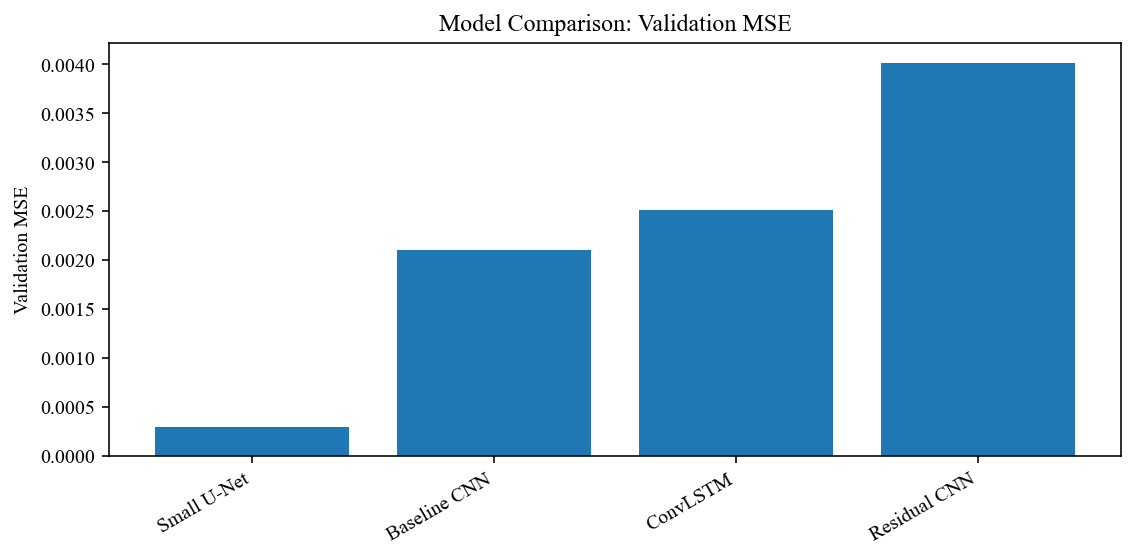

In [39]:
# %%
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["val_mse"])
plt.ylabel("Validation MSE")
plt.title("Model Comparison: Validation MSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

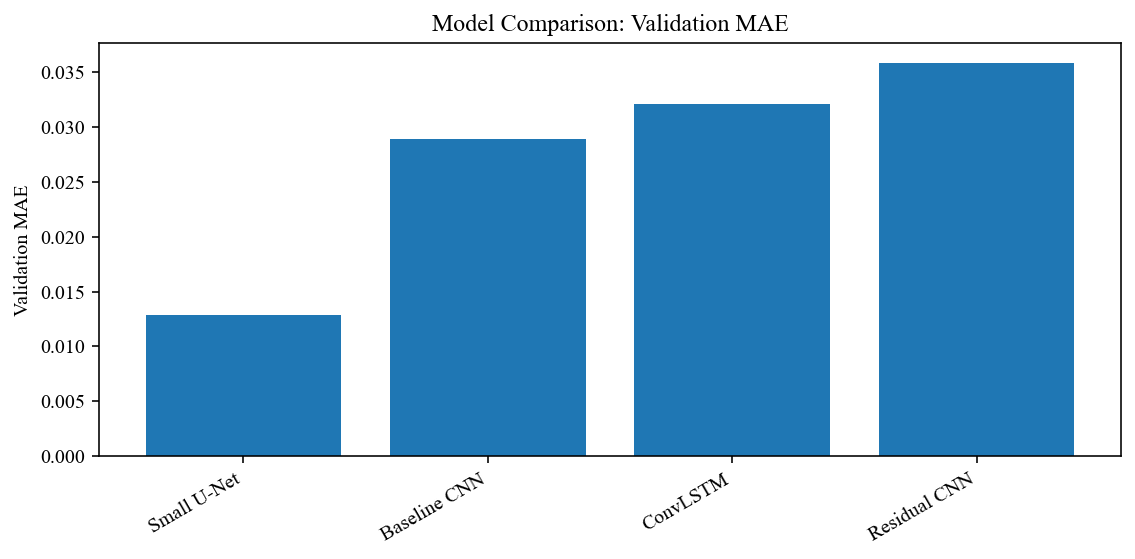

In [40]:
# %%
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["val_mae"])
plt.ylabel("Validation MAE")
plt.title("Model Comparison: Validation MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

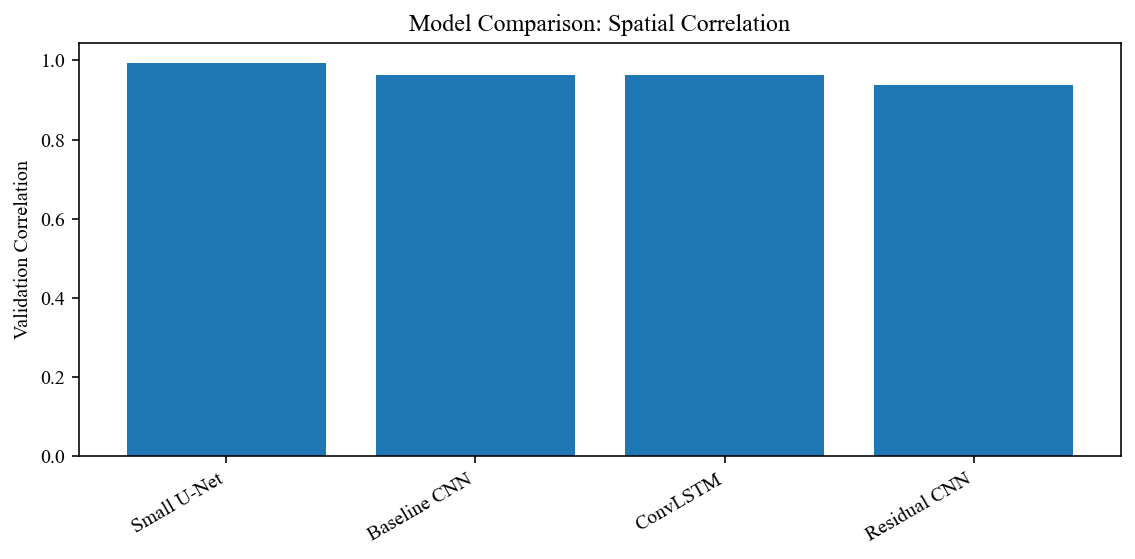

In [41]:
# %%
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["val_corr"])
plt.ylabel("Validation Correlation")
plt.title("Model Comparison: Spatial Correlation")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [42]:
# ## 13. Plot Training Curves

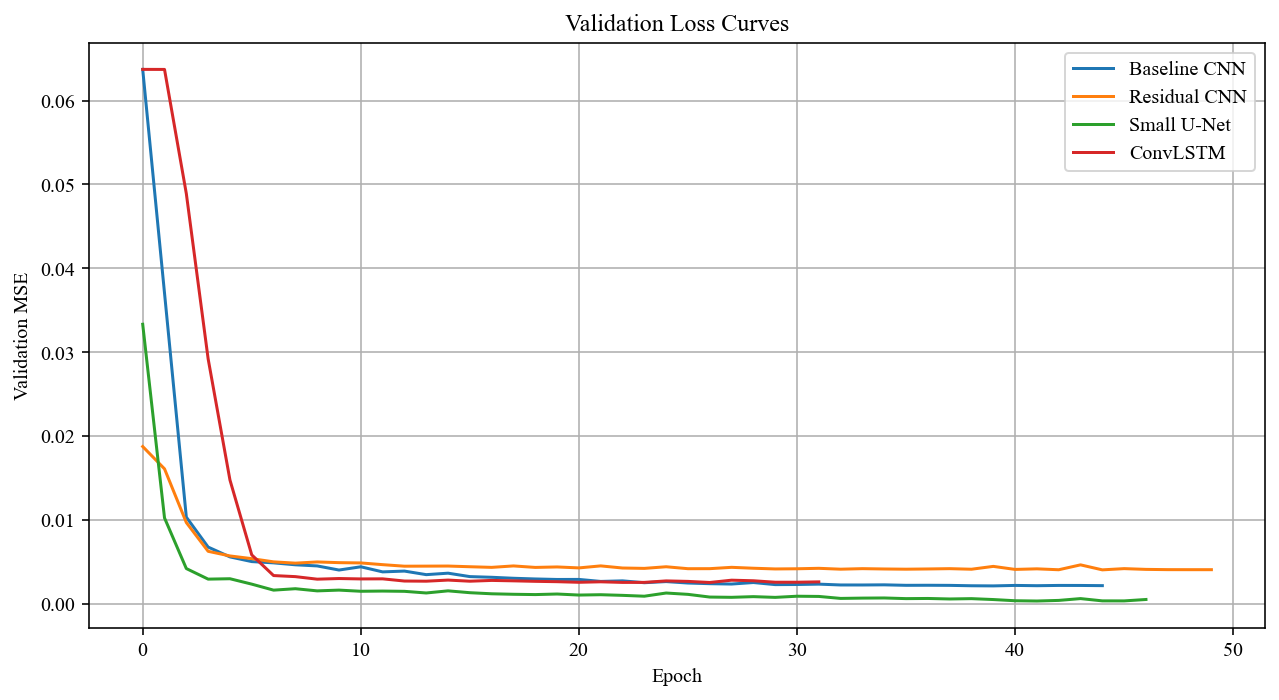

In [43]:
# %%
plt.figure(figsize=(9, 5))

for result in results:
    plt.plot(
        result["val_losses"],
        label=result["model"]
    )

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

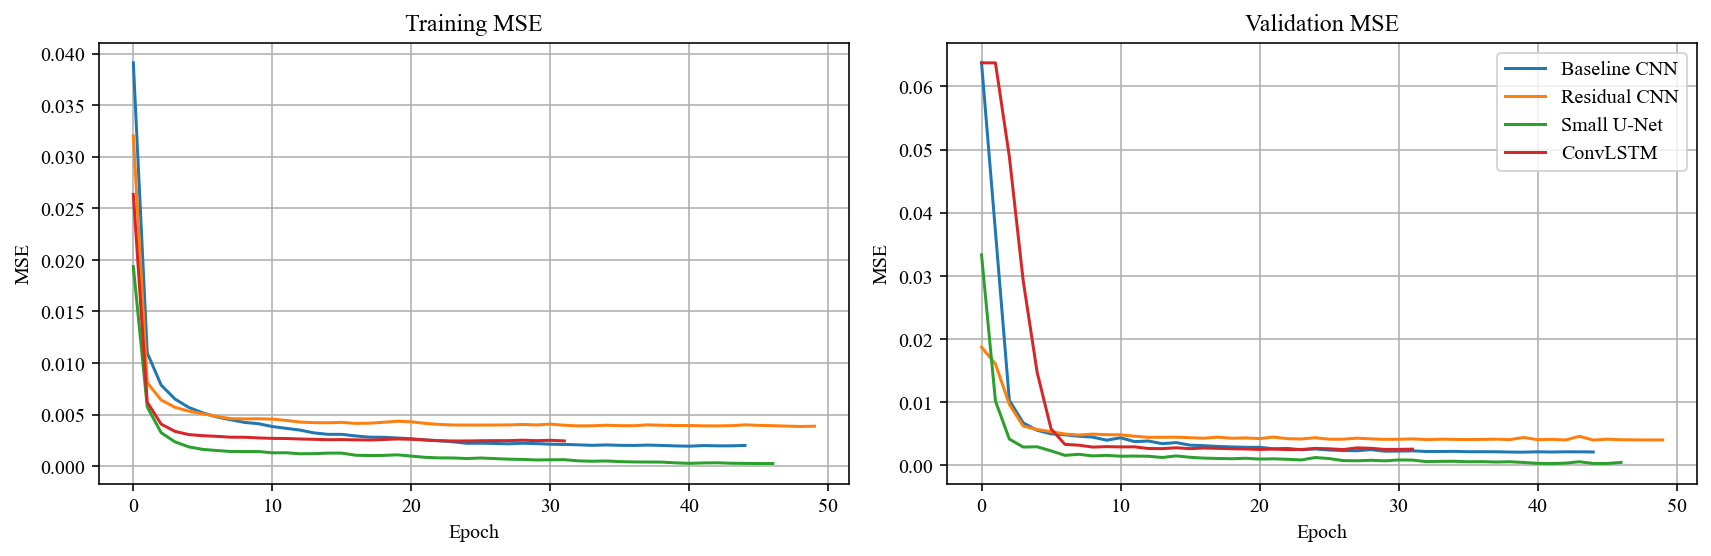

In [44]:
# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for result in results:
    axes[0].plot(result["train_losses"], label=result["model"])
    axes[1].plot(result["val_losses"], label=result["model"])

axes[0].set_title("Training MSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].grid(True)

axes[1].set_title("Validation MSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].grid(True)

axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
# ## 14. Final Timestep Prediction
#
# Use September 2025 as held-out test, consistent with the starting point script.

In [46]:
# %%
# Final timestep for spatial models
x_test_spatial = X_all[-1][np.newaxis, :, :, :]

# Final sequence for ConvLSTM
x_test_sequence = X_all[-seq_len:][np.newaxis, :, :, :, :]

true_rain = y_all[-1, 0]

print("x_test_spatial:", x_test_spatial.shape)
print("x_test_sequence:", x_test_sequence.shape)
print("true_rain:", true_rain.shape)

x_test_spatial: (1, 7, 11, 13)
x_test_sequence: (1, 3, 7, 11, 13)
true_rain: (9, 11)


In [47]:
# %%
def predict_model(model, x_input):
    model.eval()

    x_tensor = torch.tensor(
        x_input,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        pred = model(x_tensor)

    return pred.cpu().numpy()[0, 0]

In [48]:
# %%
predictions = {}

for model_name in trained_models:
    model = trained_models[model_name]

    if model_name == "ConvLSTM":
        pred = predict_model(model, x_test_sequence)
    else:
        pred = predict_model(model, x_test_spatial)

    predictions[model_name] = pred

    mse = np.mean((pred - true_rain) ** 2)
    mae = np.mean(np.abs(pred - true_rain))

    print(model_name, "test MSE:", mse, "test MAE:", mae)

Baseline CNN test MSE: 0.00195553 test MAE: 0.0266526
Residual CNN test MSE: 0.0034180512 test MAE: 0.032540157
Small U-Net test MSE: 0.00016706489 test MAE: 0.009596672
ConvLSTM test MSE: 0.002449431 test MAE: 0.030980257


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


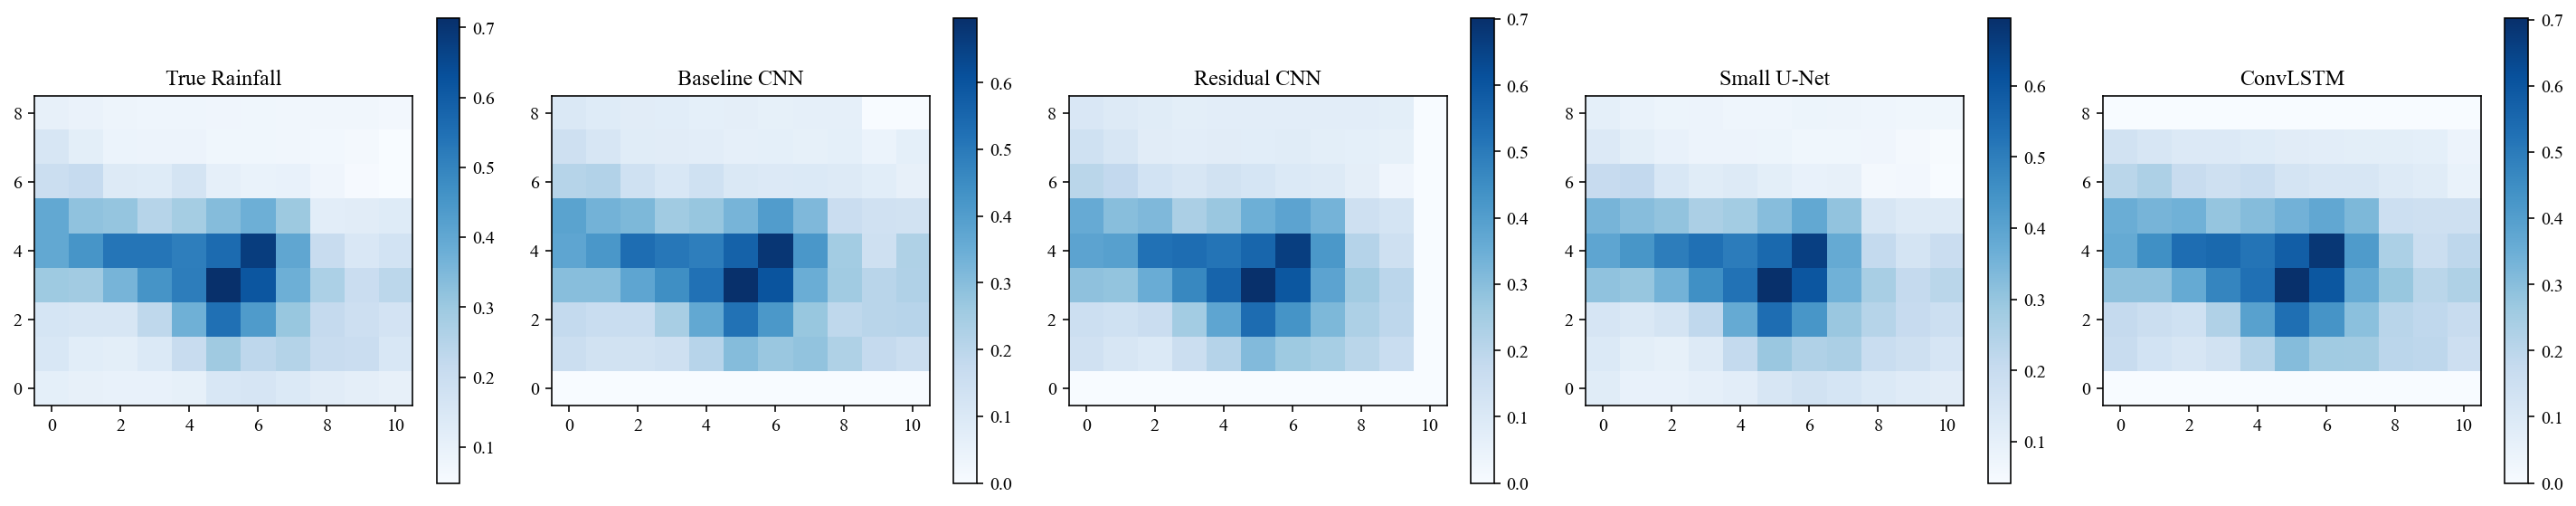

In [49]:
# %%
n_models = len(predictions)

plt.figure(figsize=(4 * (n_models + 1), 4))

plt.subplot(1, n_models + 1, 1)
plt.imshow(true_rain, origin="lower", cmap="Blues")
plt.colorbar()
plt.title("True Rainfall")

for i, (model_name, pred) in enumerate(predictions.items(), start=2):
    plt.subplot(1, n_models + 1, i)
    plt.imshow(pred, origin="lower", cmap="Blues")
    plt.colorbar()
    plt.title(model_name)

plt.tight_layout()
plt.show()

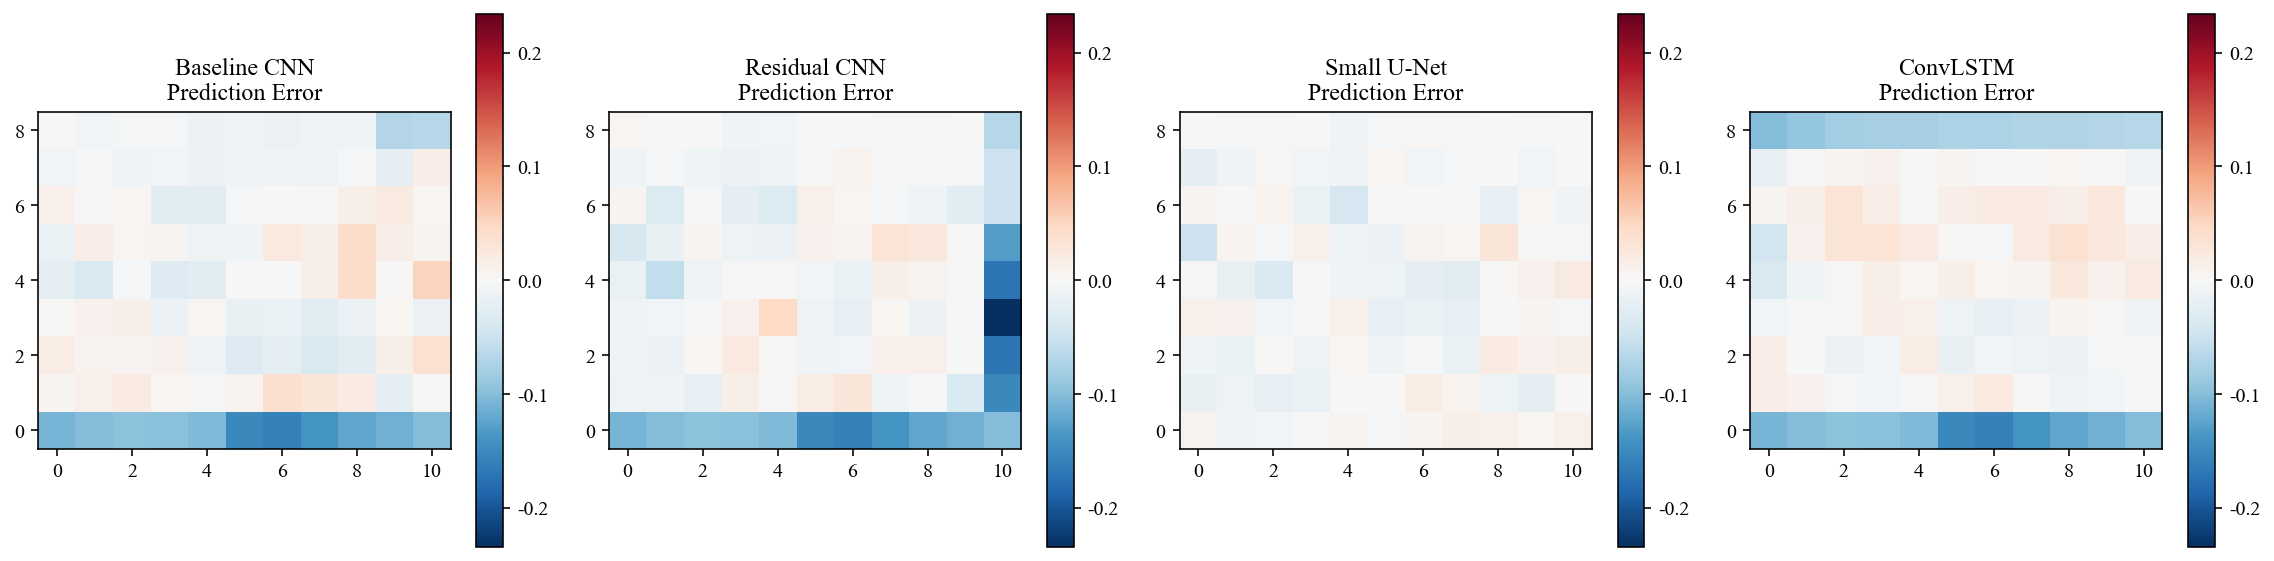

In [55]:
# Calculate shared symmetric colour scale for all models
err_max = max(
    np.abs(pred - true_rain).max()
    for pred in predictions.values()
)

plt.figure(figsize=(4 * n_models, 4))

for i, (model_name, pred) in enumerate(predictions.items(), start=1):
    error = pred - true_rain

    plt.subplot(1, n_models, i)
    plt.imshow(
        error,
        origin="lower",
        cmap="RdBu_r",
        vmin=-err_max,
        vmax=err_max
    )
    plt.colorbar()
    plt.title(f"{model_name}\nPrediction Error")

plt.tight_layout()
plt.show()

In [51]:
# ## 15. Save Model Comparison Results

In [52]:
# %%
output_path = DATA_DIR / "advanced_model_comparison.csv"
comparison_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /Users/camus/Desktop/dissertation/meeting1/RainfallWestAfrica_Resources/advanced_model_comparison.csv


In [ ]:
# ##
latitude:  0°N, 2°N, 4°N, ..., 16°N
longitude: 30°W, 27°W, 24°W, ..., 0°